###   Introduction

This project explores the behavioral, lifestyle, and psychological factors associated with depression among teenagers using a structured dataset of 1,200 adolescent respondents.

Teen mental health has become a critical global issue, particularly in the digital era, where social media exposure, sleep deprivation, academic pressure, and emotional stress increasingly affect adolescent well-being.

The dataset includes the following variables:

    Social media usage (daily hours & platform type)
    Sleep habits (hours per night)
    Academic performance
    Stress and anxiety levels
    Physical activity
    Social interaction patterns
    Addiction level

These variables are analyzed through Exploratory Data Analysis (EDA) to understand how behavioral and lifestyle patterns contribute to depression risk among teenagers aged 13–19.

Key findings from this analysis:

    Depressed teens use social media ~7 hrs/day vs ~4–5 hrs for non-depressed
    Sleep deprivation (< 5 hrs) is strongly linked to depression
    Stress and anxiety levels are the strongest predictors
    Platform type (Instagram vs TikTok) shows no significant difference
    The dataset is severely imbalanced (97.4% non-depressed : 2.6% depressed), requiring handling before modeling

PROJECT OBJECTIVE

The main objective of this project is to perform Exploratory Data Analysis (EDA) to uncover meaningful behavioral patterns associated with teen depression.

The analysis aims to:

    Identify which lifestyle habits are most associated with depression
    Detect behavioral risk indicators for early mental health decline
    Understand key differences between depressed and non-depressed teens
    Explore feature correlations and multivariate relationships
    Address class imbalance for future predictive modeling
    Support actionable insights for schools, parents, and healthcare systems

The target variable in this project is:

    depression_label (0 = Not Depressed, 1 = Depressed)

This project demonstrates how data analytics can address real-world social issues by transforming raw behavioral data into actionable mental health insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')


In [3]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [5]:
df.shape

(1200, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


Before conducting deeper analysis, it is important to understand the overall structure and characteristics of the dataset.

The dataset contains information related to teenagers' behavioral, academic, social, and psychological conditions. Each row represents an individual participant, while each column represents a specific feature associated with lifestyle habits, emotional condition, or mental health indicators.

The dataset consists of 1,200 observations and 13 variables, covering both numerical and categorical data types.

DATASET CHARACTERISTICS

The dataset includes two major feature categories:

    Numerical Variables These variables represent measurable quantitative information and are primarily used for statistical analysis, distribution analysis, correlation analysis, and predictive modeling.

Examples of numerical features include:

    Age
    Daily social media usage hours
    Sleep hours
    Screen time before sleep
    Academic performance
    Physical activity
    Stress level
    Anxiety level
    Addiction level
    Depression label

These variables help quantify behavioral intensity, lifestyle patterns, and psychological conditions associated with teen mental health.

    Categorical Variables These variables represent grouped or labeled information used to identify classifications, categories, or behavioral groups.

Examples of categorical features include:

    Gender
    Platform usage
    Social interaction level

Categorical variables are important for identifying behavioral differences between groups and understanding how certain categories relate to depression tendencies.

In [7]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:

df['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [10]:
df['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

# Checking for Outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=df.select_dtypes(include='number'), palette='Set2')
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Columns", fontweight='bold')
plt.grid(which='major', linestyle='--', linewidth=0.6, alpha=0.4)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.3)
plt.show()

####   EXPLORATORY DATA ANALYSIS

- Univariate analysis

-- Numerical Features

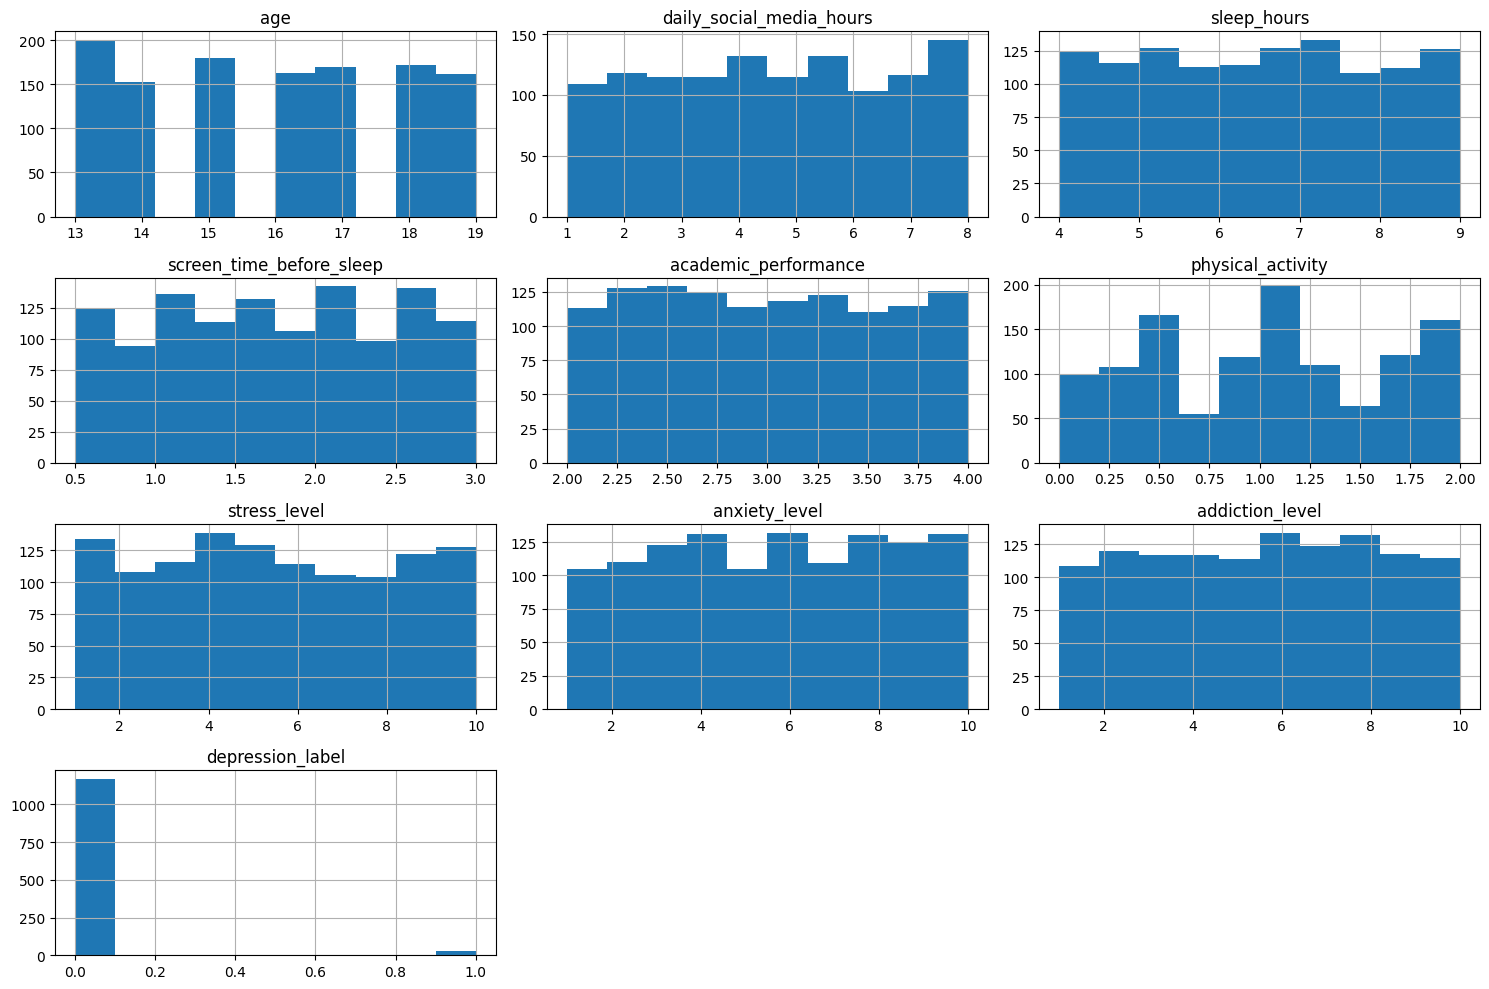

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

**Explanation**

- Age is fairly balanced across 13–19 years, ensuring diverse representation.
- Most teens spend 3–8 hours/day on social media, indicating heavy digital engagement.
- Sleep duration clusters around 6–8 hours, which is within healthy range for most respondents — but depressed teens show significantly lower values.
- Stress and anxiety levels are widely spread (1–10), reflecting the diverse mental health landscape in the dataset.
- Physical activity varies greatly, with some teens reporting zero activity — a potential risk factor.
- The `depression_label` is highly imbalanced: ~1,169 non-depressed vs ~31 depressed, which must be addressed before any predictive modeling.

###  Categorical Distribution

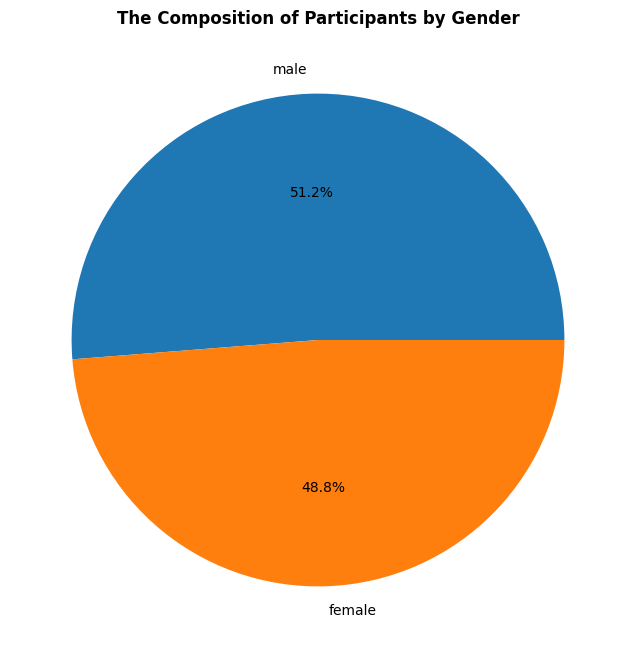

In [12]:
counts = df['gender'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("The Composition of Participants by Gender", fontweight='bold')
plt.show()

C:\Users\kelvi\AppData\Local\Temp\ipykernel_18608\1955253256.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


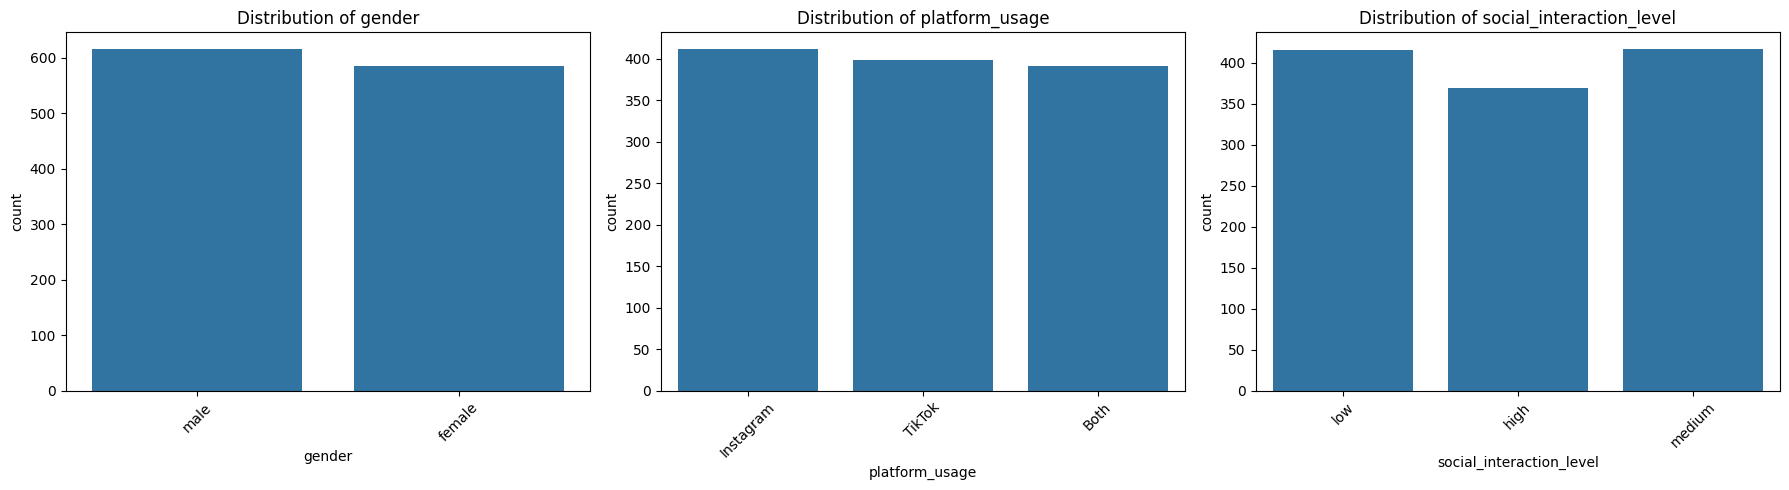

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Explanation

    Platform usage is roughly balanced across Instagram, TikTok, and Both, meaning the dataset does not over-represent any single platform.
    Gender distribution is approximately equal between male and female respondents.
    Social interaction level (low/medium/high) is evenly distributed, allowing fair comparison across groups.

Key takeaway: No categorical variable alone creates a strong class separation. Platform type, gender, and social interaction level are not dominant predictors — behavioral and psychological variables carry more predictive weight.


###  Bivariate Analysis

## Violin plot

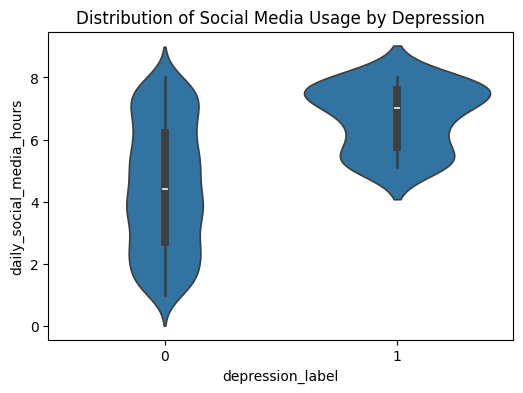

In [14]:
plt.figure(figsize=(6,4))
sns.violinplot(x='depression_label', y='daily_social_media_hours', data=df)
plt.title("Distribution of Social Media Usage by Depression")
plt.show()

 Explanation

    Depressed teens (label 1) average ~7 hrs/day with a tight, consistent distribution (6–8 hrs).
    Non-depressed teens (label 0) average ~4–5 hrs/day with a much wider spread (0–9 hrs).
    Users with < 3 hrs/day are almost exclusively non-depressed.
    The overlap zone (4–9 hrs) means high usage alone cannot definitively indicate depression — it is a contributing signal, not a standalone predictor.

Insight:

Social media usage is a meaningful differentiating feature, but must be combined with other variables for reliable interpretation.


 ###  KDE Plot (Density Comparison)

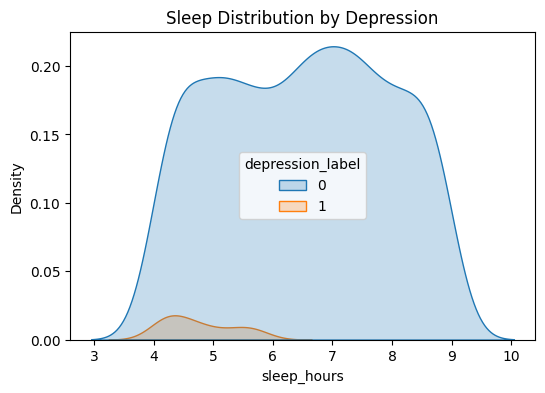

In [15]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='sleep_hours', hue='depression_label', fill=True)
plt.title("Sleep Distribution by Depression")
plt.show()

Explanation

    Non-depressed teens (label 0) show a wide, healthy distribution peaking at 5–7 hrs/night.
    Depressed teens (label 1) show a narrow, flat distribution concentrated at 3–5 hrs/night — indicating consistently poor sleep.
    Very few depressed teens sleep more than 6 hours, suggesting sleep deprivation is closely associated with depression in this dataset.

Insight :

Sleep duration is one of the most distinguishable features between the two groups. It may serve as a simple, accessible early-warning indicator for mental health risk.


##   Stacked Bar Chart

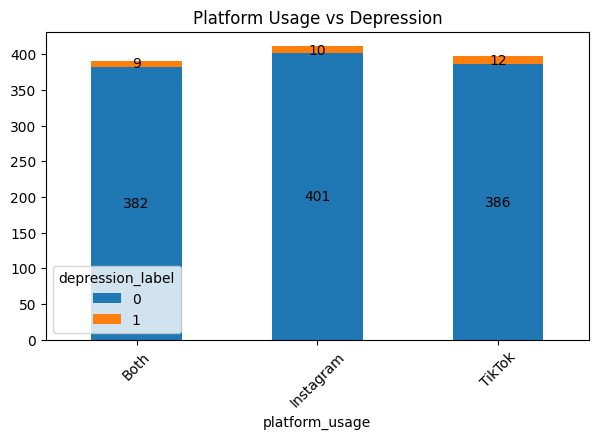

In [16]:
ct = pd.crosstab(df['platform_usage'], df['depression_label'])

ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4)
)

plt.title("Platform Usage vs Depression")
plt.xticks(rotation=45)

# Tambahkan label nominal
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.show()

Explanation

    Depression cases are minimal and evenly distributed across Instagram, TikTok, and Both platforms.
    No single platform shows a notably higher proportion of depressed users.

Insight:

Platform type is NOT a key differentiating factor for depression. The risk comes from the duration and pattern of usage, not the platform itself. This finding suggests that intervention strategies should focus on screen time management rather than platform restriction

##   Multivariate Analysis

###  Pairplot

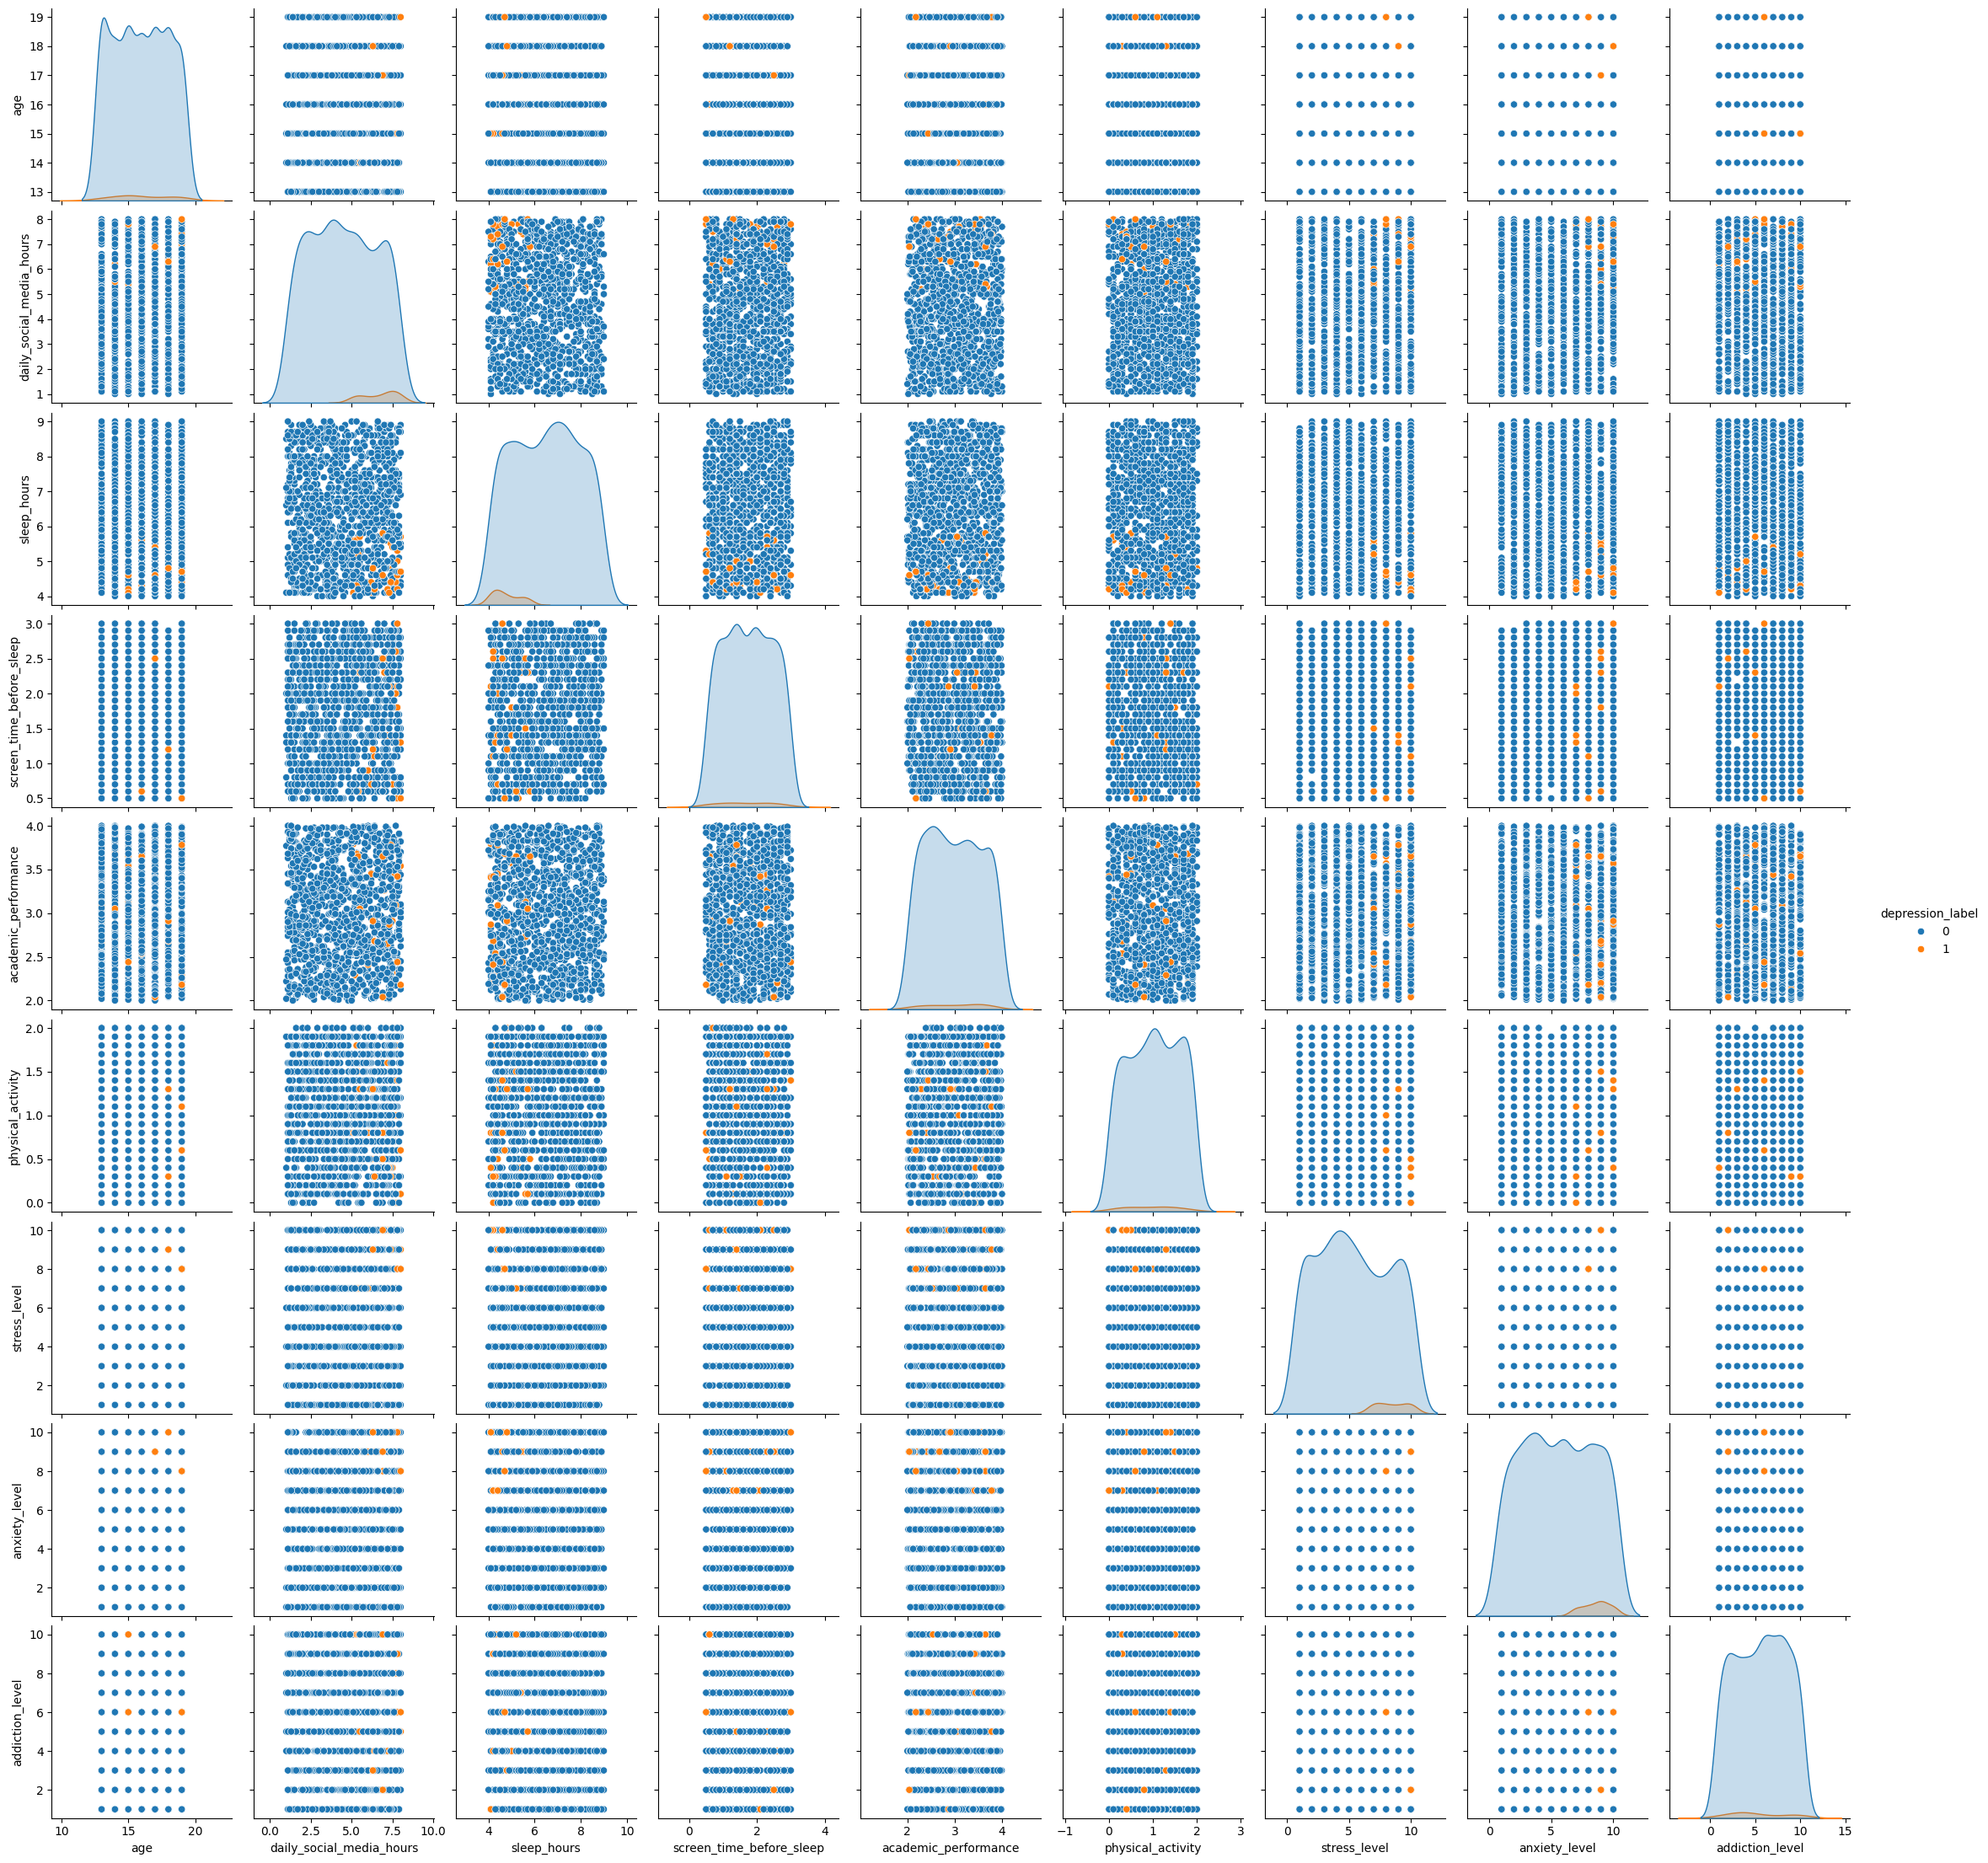

In [17]:
sns.pairplot(df, hue='depression_label')
plt.show()

###  Groupby Analysis — Mean per Feature by Depression Label


In [18]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

group_means = df.groupby('depression_label')[num_cols].mean().T
group_means.columns = ['Not Depressed (0)', 'Depressed (1)']
group_means['Difference'] = group_means['Depressed (1)'] - group_means['Not Depressed (0)']
group_means['Difference (%)'] = (group_means['Difference'] / group_means['Not Depressed (0)'] * 100).round(1)

print("=" * 70)
print("MEAN COMPARISON BY DEPRESSION LABEL")
print("=" * 70)
print(group_means.round(3).to_string())
print("=" * 70)

MEAN COMPARISON BY DEPRESSION LABEL
                          Not Depressed (0)  Depressed (1)  Difference  Difference (%)
age                                  15.925         16.065       0.140             0.9
daily_social_media_hours              4.479          6.719       2.241            50.0
sleep_hours                           6.494          4.761      -1.733           -26.7
screen_time_before_sleep              1.742          1.668      -0.075            -4.3
academic_performance                  2.990          2.995       0.005             0.2
physical_activity                     1.016          0.952      -0.065            -6.4
stress_level                          5.365          8.484       3.119            58.1
anxiety_level                         5.558          8.613       3.055            55.0
addiction_level                       5.571          5.323      -0.249            -4.5


**Explanation**

The table compares mean feature values between depressed (label 1) and
non-depressed (label 0) teens across all numerical variables.

| Feature | Key Finding |
|---|---|
| `stress_level` | +58.1% higher in depressed teens — largest difference |
| `anxiety_level` | +55.0% higher in depressed teens |
| `daily_social_media_hours` | +50.0% higher (~4.5 hrs vs ~6.7 hrs/day) |
| `sleep_hours` | -26.7% lower in depressed teens (~6.5 hrs vs ~4.8 hrs) |
| `age`, `academic_performance`, `physical_activity` | < 10% difference — negligible |

**Insight:** Only four features show meaningful group differences:
stress_level, anxiety_level, daily_social_media_hours, and sleep_hours.
The remaining five features (age, academic performance, screen time before
sleep, physical activity, addiction level) show near-zero differences,
confirming they carry little discriminative power for depression detection.

##  GROUPED MEAN BAR CHART

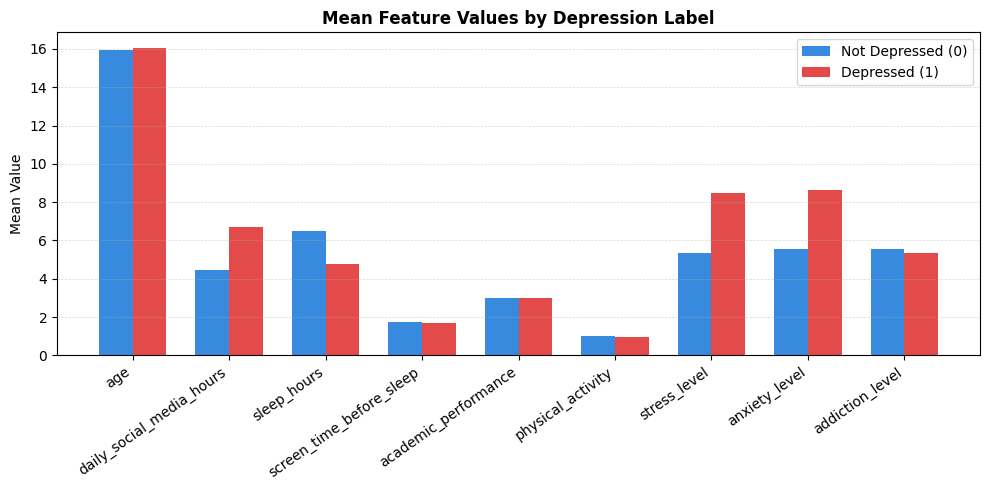

In [19]:
plot_data = group_means[['Not Depressed (0)', 'Depressed (1)']].copy()

plot_data_norm = (plot_data - plot_data.min(axis=1).values.reshape(-1,1)) / \
                 (plot_data.max(axis=1) - plot_data.min(axis=1)).values.reshape(-1,1)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(plot_data.index))
width = 0.35

bars0 = ax.bar(x - width/2, plot_data['Not Depressed (0)'], width,
               label='Not Depressed (0)', color='#378ADD', edgecolor='none')
bars1 = ax.bar(x + width/2, plot_data['Depressed (1)'], width,
               label='Depressed (1)', color='#E24B4A', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=35, ha='right')
ax.set_title('Mean Feature Values by Depression Label', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

**Explanation**

The bar chart visualizes mean feature values side-by-side for each group.
Most bars are nearly identical in height across groups, except for four
features where a clear gap is visible:

- `stress_level` and `anxiety_level`: depressed teens (red) are
  noticeably taller — means of ~8.5 vs ~5.4
- `daily_social_media_hours`: depressed teens show a higher bar
  (~6.7 vs ~4.5 hrs)
- `sleep_hours`: the only feature where the non-depressed bar
  is taller (~6.5 vs ~4.8 hrs), reflecting sleep deprivation

**Insight:** The visual gap in these four features stands out clearly
against the near-identical bars of other variables, providing a quick
at-a-glance confirmation of which behavioral dimensions actually differ
between groups.

###  Correlation Analysis

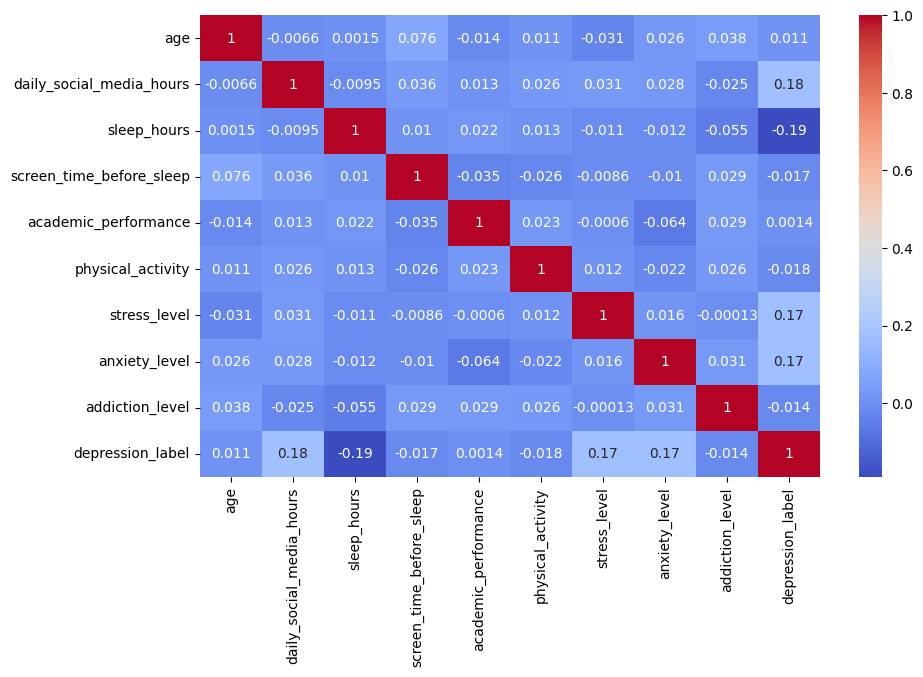

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [21]:
corr = df.corr(numeric_only=True)

corr['depression_label'].sort_values(ascending=False)

depression_label            1.000000
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64

**Explanation**
Focusing on the `depression_label` row/column:

| Feature | Correlation | Interpretation |
|---|---|---|
| `sleep_hours` | -0.19 | Less sleep → higher depression risk |
| `daily_social_media_hours` | +0.18 | More screen time → higher depression risk |
| `stress_level` | +0.17 | Higher stress → higher depression risk |
| `anxiety_level` | +0.17 | Higher anxiety → higher depression risk |
| Other features | ~0.00–0.03 | Near-zero correlation |



**Insight:**

All correlations are weak (< 0.2), meaning no single variable is a strong standalone predictor. However, the combination of these four features (sleep, social media, stress, anxiety) forms a meaningful behavioral profile for depression detection. This supports the need for multi-feature modeling rather than single-variable analysis.


###  Target Variable Analysis

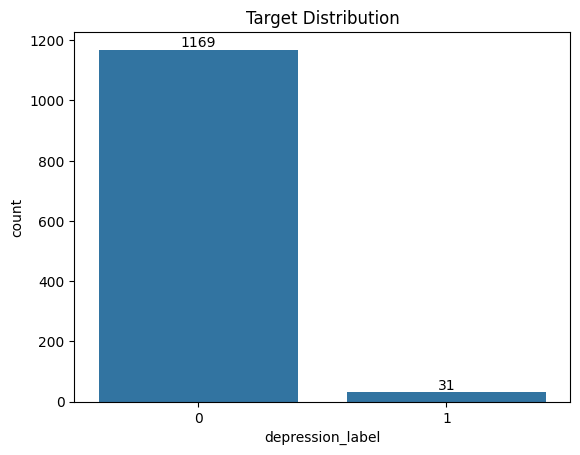

In [22]:
ax = sns.countplot(x='depression_label', data=df)

plt.title("Target Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Explanation**
- Label 0 (Not Depressed): ~1,169 samples (97.4%)
- Label 1 (Depressed): ~31 samples (2.6%)

**This severe imbalance is a critical issue for machine learning:**
- A naive model predicting all samples as label 0 achieves 97.4% accuracy, but completely fails to detect depression.
- Standard accuracy metrics are misleading — use Precision, Recall, F1-Score, and AUC-ROC instead.

**Recommended handling techniques:**
- SMOTE (Synthetic Minority Oversampling Technique)
- Random oversampling of minority class
- Class weighting in model training (class_weight='balanced')
- Stratified cross-validation

**Insight:** Addressing class imbalance is a mandatory preprocessing step before any predictive modeling on this dataset.
